# Bayesian Optimal Experimental Design — Burgers Equation Tutorial

This notebook demonstrates our BOED proposal on the 1D viscous Burgers equation.
The pipeline covers:
1. **Setup** — PDE model, noise, and discretisation
2. **Prior** — GP prior split into parameter of interest $\theta$ and nuisance $\eta$
3. **Forward model** — $G:(\theta)\mapsto u(\cdot,T)$
4. **Finite-difference Jacobians** — $J_\theta$ and their Monte-Carlo expectations
5. **Covariance matrices** — $\Sigma_Y$, $\Sigma_{\rm noise}$, $\Sigma_{\rm signal}$, $\Sigma_{Y|\theta}$
6. **EIG estimators** — upper bound (BS) and direct estimator (BI)
7. **Greedy sensor placement** comparison

## 1. Imports

In [60]:
import numpy as np
import numpy.linalg as la
import scipy.linalg as sla
import matplotlib.pyplot as plt
from scipy.stats import qmc, norm, multivariate_normal
from joblib import Parallel, delayed

from boed.priors.kernels import Matern32, Matern12
from boed.priors.gp_priors import GaussianProcessPrior
from boed.core.noise import NoiseModel, ColoredNoise
from boed.core import make_u0
from boed.pde.burgers import Burgers_CN
from boed.utils.observation import build_selection_matrices

## 2. Setup

We define the spatial grid, PDE model, true initial condition, and observation noise.

In [61]:
np.random.seed(42)

N        = 100      # number of interior grid points
dt       = 0.001
n_steps  = 100
sigma    = 0.1    # noise standard deviation
lambda_  = 0.1
n_samples = 500

x_grid = np.linspace(0, 1, N + 2)[1:-1]

model   = Burgers_CN(N=N, dt=dt, diffusivity=0.02, lambda_=lambda_)
u0_true = make_u0(x_grid, "gaussian", center=0.25, width=0.07, amplitude=1.5)
noise   = NoiseModel(sigma_noise=sigma)

## 3. Prior

The joint parameter $\theta \in \mathbb{R}^{d}$ follows a Gaussian prior:

$$
\theta \sim \mathcal{N}\!\left(m_{\theta},\;
\Sigma_{\theta} \right)
$$


In [62]:
kernel = Matern32(length_scale=0.2, sigma=1.0)
prior  = GaussianProcessPrior(kernel, mu=np.zeros(N), nx=N)

In [63]:
def _halton_normal(d: int, n: int, seed: int | None = None) -> np.ndarray:
    sampler = qmc.Halton(d=d, scramble=True, seed=seed)
    u = sampler.random(n=n)
    eps = np.finfo(float).eps
    return norm.ppf(np.clip(u, eps, 1.0 - eps))


def sample_prior(prior, n: int, seed: int | None = None) -> np.ndarray:
    mu = np.asarray(prior.mu)
    L  = np.linalg.cholesky(np.asarray(prior.Sigma))
    z  = _halton_normal(len(mu), n, seed=seed)
    return mu + (L @ z.T).T


In [64]:
# ----------------------------------------------------------------------
# 1.  Prior via KL expansion
# ----------------------------------------------------------------------
class KLPrior:
    """
    Prior = N(mu, Sigma) → représentation KL tronquée.
    theta = mu + V_k @ diag(sqrt(lam_k)) @ xi,   xi ~ N(0, I_k)
    """
    def __init__(self, mu, Sigma, energy=0.9999):
        self.mu_full = np.asarray(mu)
        ev, V = np.linalg.eigh(np.asarray(Sigma))
        ev    = ev[::-1];  V = V[:, ::-1]          # décroissant
        cumvar = np.cumsum(ev) / ev.sum()
        self.k = int(np.searchsorted(cumvar, energy)) + 1
        self.V_k      = V[:, :self.k]              # (d, k)
        self.lam_k    = ev[:self.k]                # (k,)
        self.sqrt_lam = np.sqrt(self.lam_k)        # (k,)
        # prior dans l'espace réduit : N(0, I_k)
        self.mu    = np.zeros(self.k)
        self.Sigma = np.eye(self.k)
        self.L     = np.eye(self.k)
        self.Sinv  = np.eye(self.k)
        captured = cumvar[self.k-1] * 100
        print(f"KL tronquée : {self.k} modes, {captured:.3f}% variance")

    def xi_to_theta(self, xi):
        """xi (k,) → theta (d,)"""
        return self.mu_full + self.V_k @ (self.sqrt_lam * xi)

    def make_G_reduced(self, G):
        """G_r(xi) = G( xi_to_theta(xi) )"""
        return lambda xi: G(self.xi_to_theta(xi))

    def make_J_reduced(self, J_G):
        """J_r(xi) = J_G( theta ) @ V_k @ diag(sqrt_lam)"""
        def J_reduced(xi):
            theta = self.xi_to_theta(xi)
            J = np.asarray(J_G(theta))          # (m, d)
            return J @ self.V_k @ np.diag(self.sqrt_lam)   # (m, k)
        return J_reduced

kl_prior = KLPrior(prior.mu, prior.Sigma)

KL tronquée : 46 modes, 99.990% variance


### Utility: matrix display

In [65]:
def plot_matrices(matrices, titles, figsize=None, cmap="viridis"):
    """Display a row of matrices side by side with individual colour-bars.

    Parameters
    ----------
    matrices : list of ndarray
        Square matrices to display.
    titles : list of str
        LaTeX-compatible title for each matrix.
    figsize : tuple, optional
        Figure size; defaults to (5 * n, 4).
    cmap : str, optional
        Matplotlib colour-map name.
    """
    n = len(matrices)
    if figsize is None:
        figsize = (5 * n, 4)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    if n == 1:
        axes = [axes]
    for ax, mat, title in zip(axes, matrices, titles):
        im = ax.imshow(mat, cmap=cmap)
        ax.set_title(title)
        fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

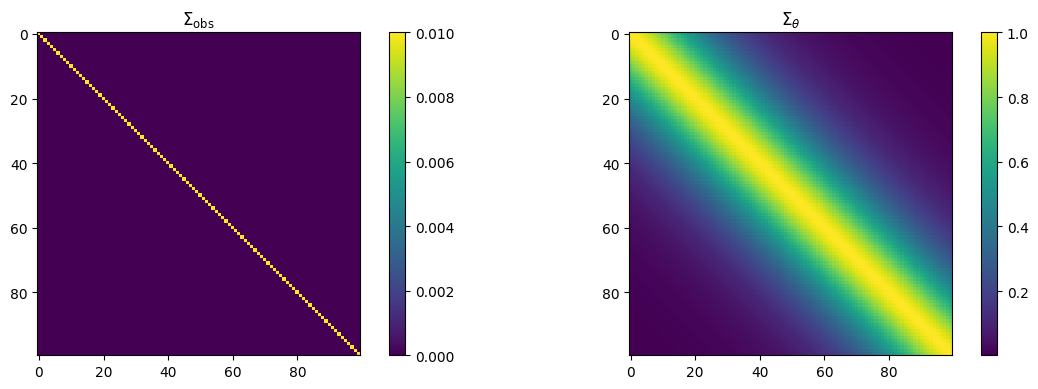

In [66]:
plot_matrices(
    [noise.get_covariance(N), prior.Sigma],
    [r"$\Sigma_{\rm obs}$", r"$\Sigma_\theta$"],
    figsize=(12, 4),
)

## 4. Forward Model

The forward operator $G:(\theta)\mapsto u(\cdot,T)\in\mathbb{R}^N$ runs the
Burgers PDE from the concatenated initial condition $\theta$.

In [67]:
def make_forward_model(pde_model, n_steps):
    """Return the forward operator G(theta, eta) -> u(·, T).

    Parameters
    ----------
    pde_model : object
        PDE solver with an ``evolve(u0, n_steps)`` method.
    n_steps : int
        Number of time steps to run.

    Returns
    -------
    G : callable
        Function ``G(theta) -> ndarray`` of shape ``(N,)``.
    """
    def G(theta: np.ndarray):
        return pde_model.evolve(u0=theta, n_steps=n_steps)[-1, :]
    return G

In [68]:
theta = u0_true.copy()
print(f"theta size : {theta.size}")

G = make_forward_model(pde_model=model, n_steps=n_steps)

# Sanity check: both calling conventions must produce the same output
u1 = G(theta=theta)
print(f"Consistency check ||G(theta,eta) - G(u0)|| = {np.linalg.norm(u1):.2e}")

theta size : 100
Consistency check ||G(theta,eta) - G(u0)|| = 4.57e+00


## 5. Finite-Difference Jacobian

$$
J_\theta(\theta) \in \mathbb{R}^{N\times d},\qquad
J_\theta \approx \frac{G(\theta+h e_j)-G(\theta-h e_j)}{2h}
$$

Cost: $2d$ forward evaluations per sample.

In [69]:
def jacobian_fd(G, theta, h=None):
    """Central finite-difference Jacobian of G with respect to theta.

    Parameters
    ----------
    G     : callable  R^d x R^q -> R^m
    theta : ndarray, shape (d,)
    h     : float, optional
        Step size.  Defaults to ``eps^{1/3} * (||theta|| + 1e-8)``.

    Returns
    -------
    J_theta : ndarray, shape (m, d)
    """
    d = theta.shape[0]
    if h is None:
        h = np.finfo(float).eps ** (1 / 3) * (la.norm(theta) + 1e-8)
    
    G_theta = G(theta)
    m = G_theta.shape[0]
    J = np.zeros((m, d))
    
    for j in range(d):
        e_j = np.zeros(d)
        e_j[j] = 1.0
        J[:, j] = (G(theta + h * e_j) - G(theta - h * e_j)) / (2 * h)
    return J

In [70]:

from functools import partial
J_G = partial(jacobian_fd, G) 


## 6. Monte-Carlo Estimation of $l_\theta$, $l_\eta$, and $l_{(\theta,\eta)}$

$$
l_\theta(u) = \mathbb{E}[J_\theta(\theta)^\top] \in \mathbb{R}^{d\times N}
$$

Samples are drawn from the **prior** $\pi_0(\theta)$ (pre-experimental setting,
no observations yet available).

In [71]:
def estimate_E_JT(G, prior, n_samples, eps=1e-6, parallel=True, n_jobs=-1):
    """
    Monte-Carlo estimate of E[J_theta^T] où J_theta est le Jacobien de G (m x d).
    Retourne une matrice (d, m).
    """
    if n_samples < 1:
        raise ValueError("n_samples must be >= 1")
    
    # Échantillons theta par Halton (quasi-MC) pour meilleure convergence
    
    theta_samples = sample_prior(prior=prior, n=n_samples, seed=42)  # (n_samples, d)

    
    # Calcul parallèle des Jacobiens pour tous les échantillons
    if parallel:
        # Chaque appel retourne J (m, d)
        Jacobians = Parallel(n_jobs=n_jobs)(
            delayed(jacobian_fd)(G, theta, eps) for theta in theta_samples
        )
    else:
        Jacobians = [jacobian_fd(G, theta, eps) for theta in theta_samples]
    
    # Somme des transposées (d, m)
    sum_JT = np.sum([J.T for J in Jacobians], axis=0)
    
    return sum_JT / n_samples

l_theta shape : (100, 100)


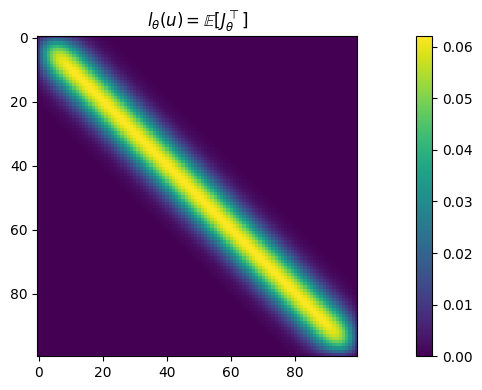

In [72]:
l_theta = estimate_E_JT(G=G, prior=prior, n_samples=n_samples)

print(f"l_theta shape : {l_theta.shape}")

plot_matrices(
    [l_theta],
    [
        r"$l_\theta(u) = \mathbb{E}[J_\theta^\top]$"
    ],
    figsize=(12, 4),
)

## 7. Monte-Carlo Estimation of $\mathcal{H}_\theta^{\Sigma_{\rm obs}}$

$$
\mathcal{H}_\theta^{\Sigma_{\rm obs}}(u)
= \mathrm{Cov}\bigl(J_\theta(\theta)^\top \Sigma_{\rm obs}^{-1/2}\bigr)
$$


In [73]:
def estimate_jacobian_covariances_mc(
    G, prior, Sigma_obs, n_samples,
    h=None, unbiased=False, rng=None, n_jobs=-1, parallel=True
):
    """Parallel version of Monte-Carlo estimation of Cov(Z_theta)."""
    Sigma_obs = np.asarray(Sigma_obs, dtype=float)
    evals, evecs = la.eigh(Sigma_obs)
    if np.any(evals <= 0):
        raise ValueError("Sigma_obs must be symmetric positive definite.")
    Sigma_inv_sqrt = evecs @ np.diag(1.0 / np.sqrt(evals)) @ evecs.T

    if rng is None:
        rng = np.random.default_rng()

    # Sample thetas using Halton or random
    theta_samples = sample_prior(prior=prior, n=n_samples, seed=142)   # (n_samples, d)

    # Compute all Z_theta in parallel
    def compute_Z(theta):
        J = jacobian_fd(G, theta, h=h)
        return J.T @ Sigma_inv_sqrt   # shape (d, m)

    if parallel:
        Z_theta_list = Parallel(n_jobs=n_jobs)(
            delayed(compute_Z)(theta) for theta in theta_samples
        )
    else:
        Z_theta_list = [compute_Z(theta) for theta in theta_samples]

    Z_theta_arr = np.array(Z_theta_list)  # (n, d, m)

    # Mean and covariance
    Z_theta_mean = np.mean(Z_theta_arr, axis=0)  # (d, m)
    d_theta = Z_theta_mean.shape[0]

    Cov_theta = np.zeros((d_theta, d_theta))

    # Accumulate (can be parallelized but usually small dimension)
    for k in range(n_samples):
        Dt = Z_theta_arr[k] - Z_theta_mean   # (d, m)
        Cov_theta += Dt @ Dt.T                # (d, d)

    denom = (n_samples - 1) if (unbiased and n_samples > 1) else n_samples
    Cov_theta /= denom
    Cov_theta = 0.5 * (Cov_theta + Cov_theta.T)

    return Cov_theta

H_theta shape      : (100, 100)


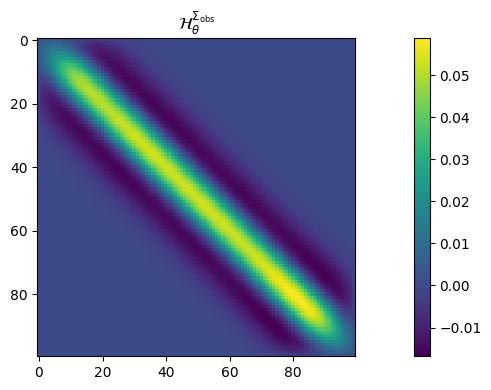

In [74]:
Cov_theta = estimate_jacobian_covariances_mc(
    G=G, prior=prior,
    Sigma_obs=noise.get_covariance(N), n_samples=n_samples,
)

print(f"H_theta shape      : {Cov_theta.shape}")

plot_matrices(
    [Cov_theta],
    [
        r"$\mathcal{H}_\theta^{\Sigma_{\rm obs}}$"
       
    ],
    figsize=(12, 4),
)

## 8. Covariance Matrices

### 8a. Marginal output covariance $\Sigma_Y$

$$
\Sigma_Y = \Sigma_{\rm obs} + \mathrm{Cov}_{\pi_0}[G(\theta,\eta)]
$$

In [75]:
def estimate_Sigma_Y(G, prior, Sigma_obs, n_samples, rng=None):
    """Estimate Sigma_Y = Sigma_obs + Cov_{pi_0}[G(theta)] by Monte Carlo.

    Samples from the joint prior.

    Parameters
    ----------
    G           : callable
    prior       : 'mu', 'Sigma', 'd'
    Sigma_obs   : ndarray (m, m)
    n_samples   : int
    rng         : np.random.Generator or None

    Returns
    -------
    Sigma_Y : ndarray (m, m)
    """
    if rng is None:
        rng = np.random.default_rng()

    m_theta = np.asarray(prior.mu)
    Sigma_theta = np.asarray(prior.Sigma)
    Sigma_obs = np.asarray(Sigma_obs, dtype=float)
    # theta_samples = rng.multivariate_normal(mean=prior.mu, cov=prior.Sigma, size=n_samples)

    sampler = qmc.Halton(d=len(prior.mu))
    samples_unif = sampler.random(n=n_samples)
    u_normal = norm.ppf(samples_unif)
    L = np.linalg.cholesky(prior.Sigma)
    theta_samples = prior.mu + (L @ u_normal.T).T   # (n_samples, d)

    U = Parallel(n_jobs=-1)(
            delayed(G)(theta_samples[k]) for k in range(n_samples))
    U = np.array(U)
    SY = Sigma_obs + np.cov(U, rowvar=False, bias=False)
    return 0.5 * (SY + SY.T)  # symmetrise


In [76]:
Sigma_Y = estimate_Sigma_Y(
    G=G, prior=prior,
    Sigma_obs=noise.get_covariance(N), n_samples=15000,
)


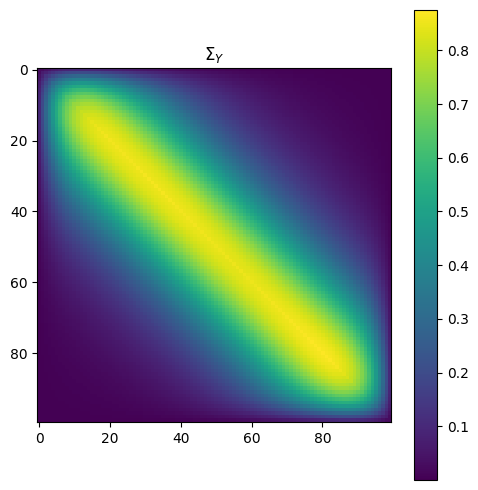

In [77]:
plot_matrices([Sigma_Y], [r"$\Sigma_Y$"], figsize=(5, 5))

### 8b. Noise covariance $\Sigma_{\rm noise}$

$$
\Sigma_{\rm noise} = \Sigma_{\rm obs}
$$

### 8c. Signal covariance $\Sigma_{\rm signal}$

$$
\Sigma_{\rm signal} = \Sigma_{\rm obs}
+ l_\theta^\top
  \left(\Sigma_\theta^{-1} + \mathcal{H}_\theta^{\Sigma_{\rm obs}}\right)^{-1}
  l_\theta
$$

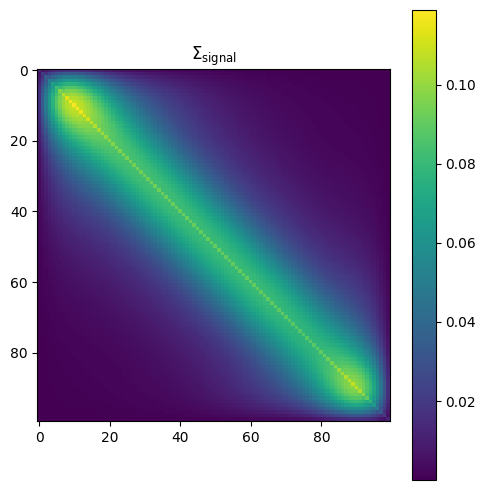

In [91]:
def compute_Sigma_signal(l_theta, H_theta, Sigma_theta, Sigma_obs):
    """Compute the signal covariance matrix.

    Parameters
    ----------
    l_theta    : ndarray (d, m)  — l_theta(u) or l_{(theta,eta)}(u)
    H_theta    : ndarray (d, d)  — H_theta^{Sigma_obs} (or full block)
    Sigma_theta: ndarray (d, d)  — prior covariance (or full joint covariance)
    Sigma_obs  : ndarray (m, m)

    Returns
    -------
    Sigma_signal : ndarray (m, m)
    """
    A = la.inv(Sigma_theta) + H_theta
    X = la.solve(A, l_theta)
    return Sigma_obs + l_theta.T @ X


Sigma_signal = compute_Sigma_signal(
    l_theta=l_theta,
    H_theta=Cov_theta,
    Sigma_theta=prior.Sigma,
    Sigma_obs=noise.get_covariance(N),
)

plot_matrices([Sigma_signal], [r"$\Sigma_{\rm signal}$"], figsize=(5, 5))

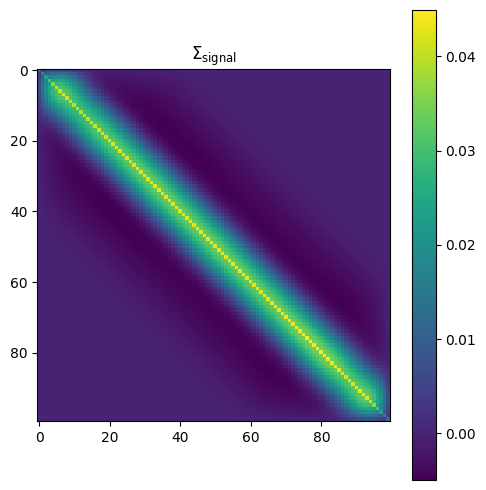

In [80]:
def compute_Sigma_signal_misfit(l_theta, H_theta, Sigma_theta, Sigma_obs):
    """
    Compute the signal covariance matrix.

    Parameters
    ----------
    l_theta     : ndarray (d, m)
    H_theta     : ndarray (d, d)
    Sigma_theta : ndarray (d, d)
    Sigma_obs   : ndarray (m, m)

    Returns
    -------
    Sigma_signal : ndarray (m, m)
    """

    # Symmetric square root of Sigma_theta
    eigvals, eigvects = np.linalg.eigh(Sigma_theta)

    # Numerical safeguard
    eigvals = np.clip(eigvals, 0.0, None)

    Sigma_theta_sqrt = (
        eigvects
        @ np.diag(np.sqrt(eigvals))
        @ eigvects.T
    )

    H_misfit = (
        Sigma_theta_sqrt
        @ H_theta
        @ Sigma_theta_sqrt
    )

    I_plus_H_misfit = np.eye(H_misfit.shape[0]) + H_misfit

    A = (
        Sigma_theta_sqrt
        @ la.solve(I_plus_H_misfit, Sigma_theta_sqrt)
    )

    X = la.solve(A, l_theta)

    return Sigma_obs + l_theta.T @ X


Sigma_signal = compute_Sigma_signal_misfit(
    l_theta=l_theta,
    H_theta=Cov_theta,
    Sigma_theta=prior.Sigma,
    Sigma_obs=noise.get_covariance(N),
)

plot_matrices([Sigma_signal], [r"$\Sigma_{\rm signal}$"], figsize=(5, 5))

### 8d. Conditional output covariance $\Sigma_{Y|\theta}$

$$
\Sigma_{Y|\theta} = \Sigma_{\rm obs}
$$

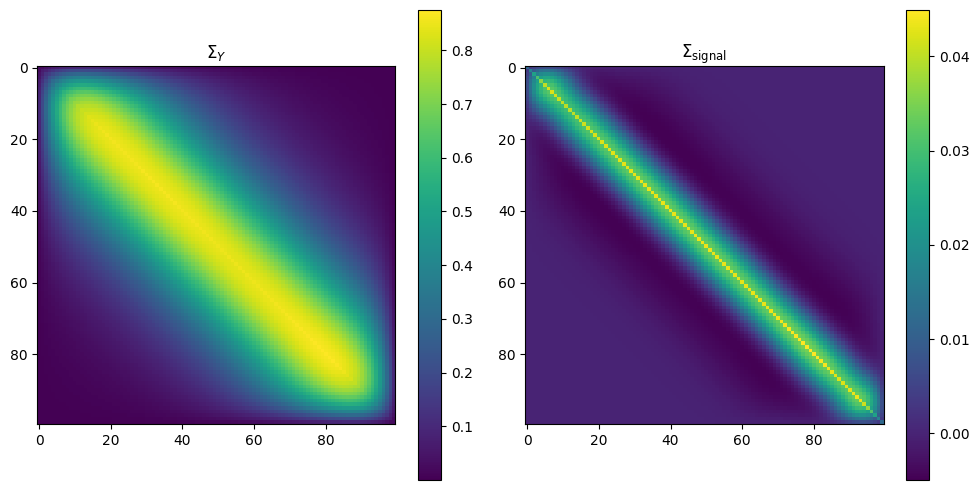

relative error 2 Sigma_Y, Sigma_signal : 95.70017738437262 %
relative error fro Sigma_Y, Sigma_signal : 98.55100866132852 %


In [81]:
plot_matrices([Sigma_Y,Sigma_signal], [r"$\Sigma_{Y}$",r"$\Sigma_{\rm signal}$"], figsize=(10, 5))
print(f"relative error 2 Sigma_Y, Sigma_signal : {np.linalg.norm(Sigma_Y-Sigma_signal,ord='nuc')*100/np.linalg.norm(Sigma_Y,ord='nuc')} %")
print(f"relative error fro Sigma_Y, Sigma_signal : {np.linalg.norm(Sigma_Y-Sigma_signal,ord='fro')*100/np.linalg.norm(Sigma_Y,ord='fro')} %")

## 9. Gradient-Free based

### Noise covariance $\Sigma_{\rm noise}$

$$
\Sigma_{\mathrm{noise}}^{-1} \succeq \mathbb{E}\!\left[\mathcal{I}_{Y\mid\theta}\right]
$$


### Signal covariance $\Sigma_{\rm signal}$

$$
\Sigma_{\mathrm{signal}}^{-1} \succeq \mathcal{I}_Y
$$

We have equality in the linear gaussian case


### Standard setting : $\mathcal{I}_Y = \Sigma_{\rm obs}^{-1} - \Sigma_{\rm obs}^{-1} \mathbb{E}\left[Cov\left(u(\theta)|Y\right)\right] \Sigma_{\rm obs}^{-1}$

In [24]:
def solve_linear_matrix_regression_minimization(
    G, prior, Sigma_obs, n_samples=10000, random_state=0,
):
    """
    Solve the affine matrix-valued regression problem

        min_{A,b} E[(X - A Y - b)(X - A Y - b)^T],

    where
        theta ~ N(m_theta, Sigma_theta),
        X = u(theta),
        Y = X + eps,
        eps ~ N(0, Sigma_obs), independent.

    Returns
    -------
    A_star : ndarray, shape (p, p)
        Optimal linear matrix.
    b_star : ndarray, shape (p,)
        Optimal intercept.
    M_emp : ndarray, shape (p, p)
        Empirical residual matrix:
            E[(X - A*Y - b*)(X - A*Y - b*)^T]
    M_formula : ndarray, shape (p, p)
        Same quantity computed from covariance formula:
            Sigma_X - Sigma_X (Sigma_X + Sigma_obs)^(-1) Sigma_X
    stats : dict
        Extra moments and samples.
    """
    rng = np.random.default_rng(random_state)

    m_theta = np.asarray(prior.mu)
    Sigma_theta = np.asarray(prior.Sigma)
    Sigma_obs = np.asarray(Sigma_obs)

    d = m_theta.shape[0]
    theta = rng.multivariate_normal(m_theta, Sigma_theta, size=n_samples)

    X = Parallel(n_jobs=-1)(
            delayed(G)(th) for th in theta)
    X = np.array(X)
    if X.ndim != 2:
        raise ValueError("u(theta) must return a 1D array with fixed length p.")

    n, p = X.shape
    if Sigma_obs.shape != (p, p):
        raise ValueError(f"Sigma_obs must have shape ({p}, {p}).")

    eps = rng.multivariate_normal(np.zeros(p), Sigma_obs, size=n_samples)
    Y = X + eps

    m_X = X.mean(axis=0)
    m_Y = Y.mean(axis=0)

    Xc = X - m_X
    Yc = Y - m_Y

    # Empirical covariances
    Sigma_XY = (Xc.T @ Yc) / n
    Sigma_YY = (Yc.T @ Yc) / n
    Sigma_X = (Xc.T @ Xc) / n

    # Optimal affine predictor X ≈ A Y + b
    A_star = Sigma_XY @ np.linalg.inv(Sigma_YY)
    b_star = m_X - A_star @ m_Y

    # Residual matrix at optimum
    R = X - (Y @ A_star.T + b_star)
    M_emp = (R.T @ R) / n

    # Closed-form matrix for this minimization problem
    M_formula = Sigma_X - Sigma_X @ np.linalg.inv(Sigma_X + Sigma_obs) @ Sigma_X

    stats = {
        "m_X": m_X,
        "m_Y": m_Y,
        "Sigma_X": Sigma_X,
        "Sigma_XY": Sigma_XY,
        "Sigma_YY": Sigma_YY,
        "X": X,
        "Y": Y,
        "residuals": R,
    }

    return A_star, b_star, M_emp, M_formula, stats

In [25]:
A_star, b_star, M_emp, M_formula, stats = solve_linear_matrix_regression_minimization(
    G = G,
    prior = prior,
    Sigma_obs = noise.get_covariance(N),
    n_samples=20000,
    random_state=0,
)


In [26]:
print(M_emp.shape)
print(A_star.shape)
print(b_star.shape)
print(stats["residuals"].shape)

(100, 100)
(100, 100)
(100,)
(20000, 100)


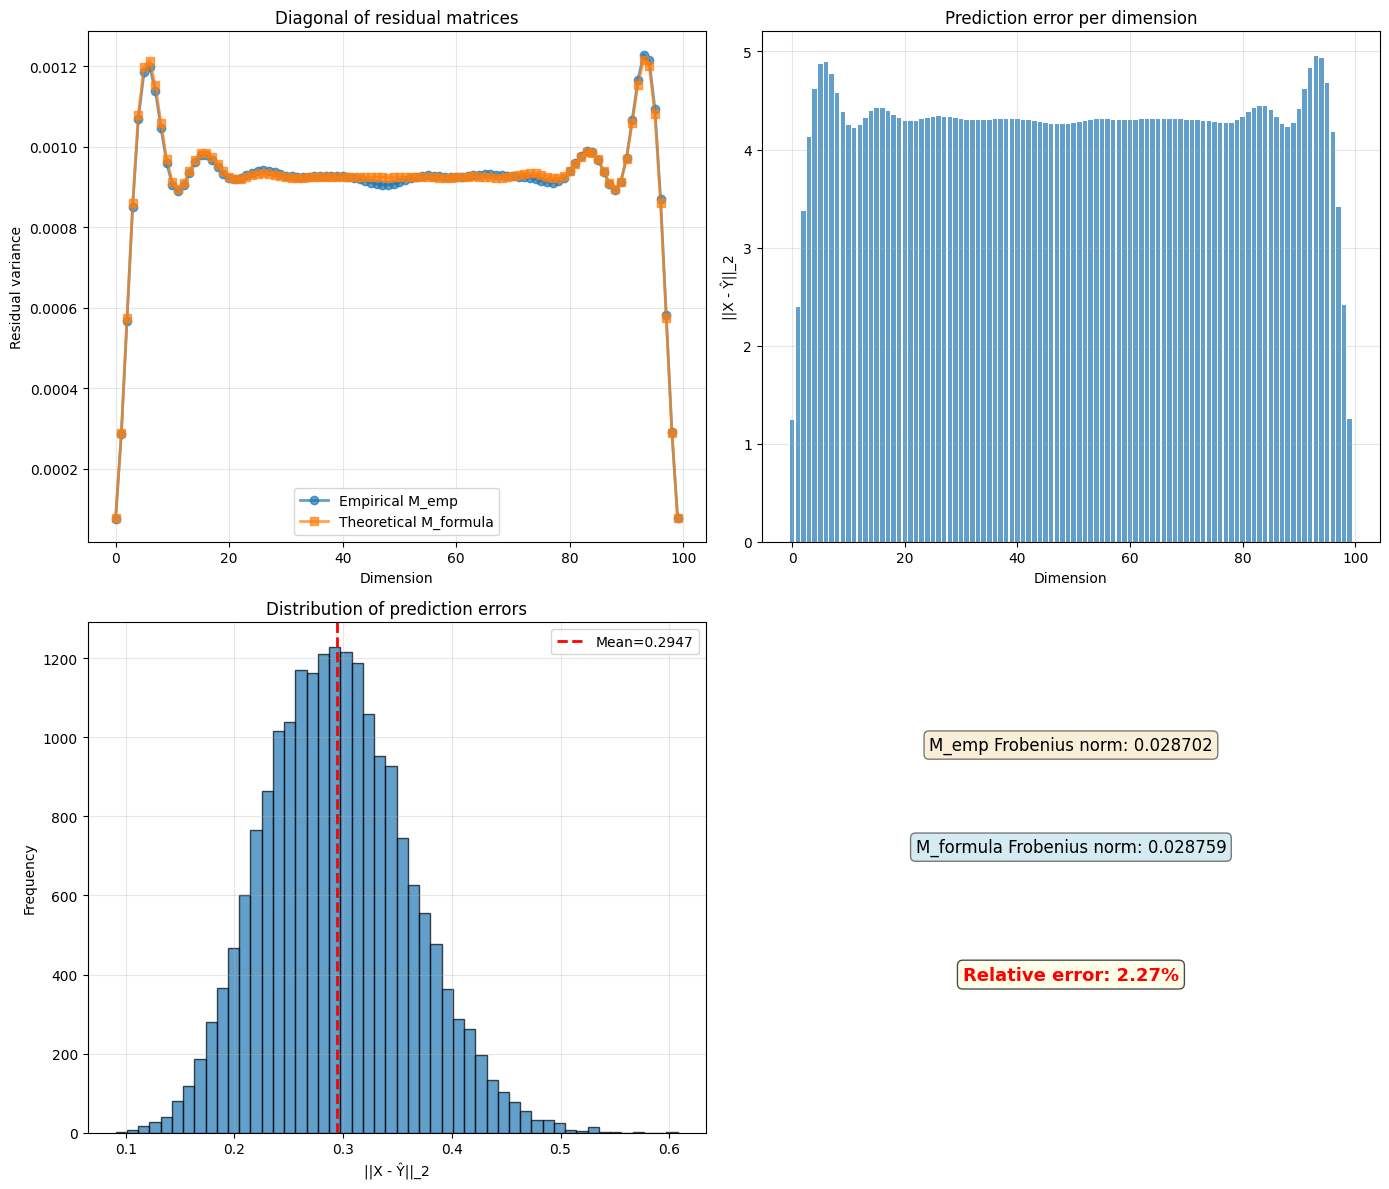


=== Linear Matrix Regression Quality Check ===
M_emp Frobenius norm:     0.02870168
M_formula Frobenius norm: 0.02875928
Relative error (Fro):     2.2681%
Mean prediction error:    0.29472135
Std prediction error:     0.06631669


In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Résidus empiriques vs théoriques (diagonale)
ax = axes[0, 0]
diag_emp = np.diag(M_emp)
diag_form = np.diag(M_formula)
ax.plot(diag_emp, label='Empirical M_emp', marker='o', alpha=0.7, linewidth=2)
ax.plot(diag_form, label='Theoretical M_formula', marker='s', alpha=0.7, linewidth=2)
ax.set_xlabel('Dimension')
ax.set_ylabel('Residual variance')
ax.set_title('Diagonal of residual matrices')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Erreur de prédiction par dimension
ax = axes[0, 1]
Y_pred = stats["Y"] @ A_star.T + b_star
pred_errors = np.linalg.norm(stats["X"] - Y_pred, axis=0)
ax.bar(range(len(pred_errors)), pred_errors, alpha=0.7)
ax.set_xlabel('Dimension')
ax.set_ylabel('||X - Ŷ||_2')
ax.set_title('Prediction error per dimension')
ax.grid(True, alpha=0.3)

# 3. Histogramme des erreurs de prédiction globales
ax = axes[1, 0]
global_errors = np.linalg.norm(stats["X"] - Y_pred, axis=1)
ax.hist(global_errors, bins=50, edgecolor='black', alpha=0.7)
ax.axvline(global_errors.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean={global_errors.mean():.4f}')
ax.set_xlabel('||X - Ŷ||_2')
ax.set_ylabel('Frequency')
ax.set_title(f'Distribution of prediction errors')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Relation empirique vs théorique (Frobenius norm)
ax = axes[1, 1]
ax.text(0.5, 0.75, f'M_emp Frobenius norm: {np.linalg.norm(M_emp, "fro"):.6f}', 
        ha='center', fontsize=12, transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.text(0.5, 0.55, f'M_formula Frobenius norm: {np.linalg.norm(M_formula, "fro"):.6f}', 
        ha='center', fontsize=12, transform=ax.transAxes, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
rel_error = np.linalg.norm(M_emp - M_formula, "fro") / np.linalg.norm(M_formula, "fro")
ax.text(0.5, 0.30, f'Relative error: {rel_error*100:.2f}%', 
        ha='center', fontsize=13, transform=ax.transAxes, color='red', weight='bold',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))
ax.axis('off')

plt.tight_layout()
plt.show()

print(f"\n=== Linear Matrix Regression Quality Check ===")
print(f"M_emp Frobenius norm:     {np.linalg.norm(M_emp, 'fro'):.8f}")
print(f"M_formula Frobenius norm: {np.linalg.norm(M_formula, 'fro'):.8f}")
print(f"Relative error (Fro):     {rel_error*100:.4f}%")
print(f"Mean prediction error:    {global_errors.mean():.8f}")
print(f"Std prediction error:     {global_errors.std():.8f}")

### Optional: Quadratic regression (not executed by default)

In [28]:
def solve_quadratic_matrix_regression_option1(
    G, prior, Sigma_obs, n_samples=10000, random_state=0,
):
    """
    Solve the quadratic matrix-valued regression problem (Option 1)

    For each dimension j:
        X_j ≈ c_j + B_j^T Y + Y^T A_j Y
        
    where:
        theta ~ N(m_theta, Sigma_theta),
        X = u(theta),
        Y = X + eps,
        eps ~ N(0, Sigma_obs), independent.
        
    A_j is (p, p) symmetric, B_j is (p,), c_j is scalar

    Returns
    -------
    A_star : list of ndarray
        Optimal quadratic matrices, one (p, p) matrix per dimension.
    B_star : ndarray, shape (p, p)
        Optimal linear coefficient matrix (each row is B_j).
    c_star : ndarray, shape (p,)
        Optimal intercepts.
    M_emp : ndarray, shape (p, p)
        Empirical residual matrix.
    M_formula : ndarray, shape (p, p)
        Theoretical residual matrix (placeholder).
    stats : dict
        Extra moments and samples.
    """
    rng = np.random.default_rng(random_state)

    m_theta = np.asarray(prior.mu)
    Sigma_theta = np.asarray(prior.Sigma)
    Sigma_obs = np.asarray(Sigma_obs)

    d = m_theta.shape[0]
    theta = rng.multivariate_normal(m_theta, Sigma_theta, size=n_samples)

    X = np.asarray([G(th) for th in theta])
    if X.ndim != 2:
        raise ValueError("u(theta) must return a 1D array with fixed length p.")

    n, p = X.shape
    if Sigma_obs.shape != (p, p):
        raise ValueError(f"Sigma_obs must have shape ({p}, {p}).")

    eps = rng.multivariate_normal(np.zeros(p), Sigma_obs, size=n_samples)
    Y = X + eps

    m_X = X.mean(axis=0)
    m_Y = Y.mean(axis=0)

    Xc = X - m_X
    Yc = Y - m_Y
    
    # Compute quadratic features: for each sample i, compute vec(Y_i Y_i^T)
    # where Y_i Y_i^T is the outer product, shape (p, p)
    YYT_list = []
    for i in range(n):
        YYT = np.outer(Y[i], Y[i])
        YYT_list.append(YYT.flatten())
    
    YYT_vec = np.array(YYT_list)  # (n, p^2)
    
    # Design matrix: [vec(Y_i Y_i^T), Y_i, 1]
    Z = np.hstack([YYT_vec, Y, np.ones((n, 1))])  # (n, p^2 + p + 1)
    
    # Solve normal equations for all p dimensions at once
    ZTZ = Z.T @ Z
    ZTX = Z.T @ X
    
    coeffs = np.linalg.solve(ZTZ, ZTX)  # (p^2 + p + 1, p)
    
    # Extract A_j, B_j, c_j for each dimension j
    A_star = []
    B_star = np.zeros((p, p))
    c_star = np.zeros(p)
    
    for j in range(p):
        A_j = coeffs[:p*p, j].reshape(p, p)
        B_j = coeffs[p*p:p*p+p, j]
        c_j = coeffs[p*p+p, j]
        
        A_star.append(A_j)
        B_star[j, :] = B_j
        c_star[j] = c_j
    
    # Predictions and residuals
    X_pred = np.zeros_like(X)
    for i in range(n):
        for j in range(p):
            quad_term = Y[i] @ A_star[j] @ Y[i]
            lin_term = Y[i] @ B_star[j]
            X_pred[i, j] = c_star[j] + lin_term + quad_term
    
    R = X - X_pred
    M_emp = (R.T @ R) / n
    
    # Theoretical residual matrix (simplified for now)
    M_formula = M_emp.copy()

    stats = {
        "m_X": m_X,
        "m_Y": m_Y,
        "X": X,
        "Y": Y,
        "Y_pred": X_pred,
        "residuals": R,
    }

    return A_star, B_star, c_star, M_emp, M_formula, stats


### Gradient-free estimate of $\Sigma_{\rm signal}$

From the Fisher information:
$$
\mathcal{I}_Y = \Sigma_{\rm obs}^{-1} - \Sigma_{\rm obs}^{-1}\,
  \mathbb{E}[\mathrm{Cov}(u(\theta)|Y)]\,\Sigma_{\rm obs}^{-1},
  \qquad \Sigma_{\rm signal\ free} = \mathcal{I}_Y^{-1}
$$

In [29]:
Sigma_obs = noise.get_covariance(N)
Sobs_inv = np.linalg.inv(Sigma_obs)
Iy = Sobs_inv @ (np.eye(N) - M_formula @ Sobs_inv)
Sigma_signal_free = np.linalg.inv(Iy)

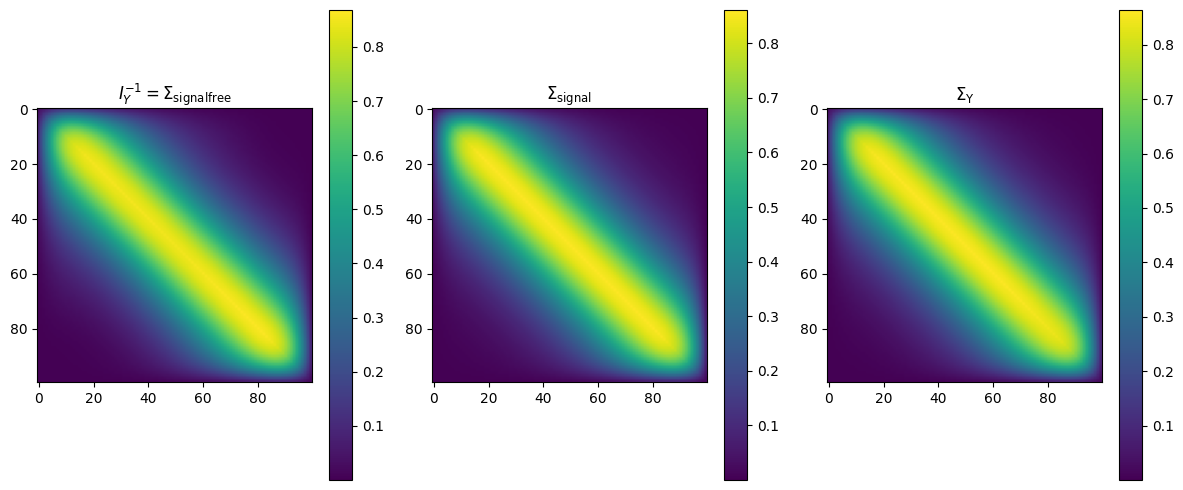

In [30]:
plot_matrices([Sigma_signal_free, Sigma_signal,Sigma_Y], [r"$I_Y^{-1} = \Sigma_{\rm signal free}$",r"$\Sigma_{\rm signal}$",r"$\Sigma_{\rm Y}$"], figsize=(12, 5))

In [31]:
print(f"relative error nuc in %: {np.round(np.linalg.norm(Sigma_signal-Sigma_Y,ord='nuc')*100/np.linalg.norm(Sigma_Y,ord='nuc'),2)} %")
print(f"relative error fro in %: {np.round(np.linalg.norm(Sigma_signal_free-Sigma_signal,ord='fro')*100/np.linalg.norm(Sigma_signal,ord='nuc'),2)} %")
print(f"relative error nuc in %: {np.round(np.linalg.norm(Sigma_signal_free-Sigma_Y,ord='nuc')*100/np.linalg.norm(Sigma_Y,ord='nuc'),2)} %")
print(f"relative error fro in %: {np.round(np.linalg.norm(Sigma_signal_free-Sigma_Y,ord='fro')*100/np.linalg.norm(Sigma_Y,ord='nuc'),2)} %")

relative error nuc in %: 0.56 %
relative error fro in %: 0.92 %
relative error nuc in %: 1.91 %
relative error fro in %: 1.16 %


## 10. EIG Estimators

For a sensor-selection matrix $W \in \mathbb{R}^{N\times s}$, we define the
**relative** EIG gain (over the full-observation design $I_N$):

$$
\Delta\mathrm{EIG}(W) = \mathrm{EIG}(W) - \mathrm{EIG}(I_N)
= \frac{1}{2}\log\frac{\det(W^\top A\, W)}{\det(W^\top B\, W)}
  - \frac{1}{2}\log\frac{\det(A)}{\det(B)}
$$

where $(A,B)$ is $(\Sigma_{\rm signal}, \Sigma_{\rm obs})$ for the **upper bound (BS)**
and $(\Sigma_Y, \Sigma_{\rm obs})$ for the **direct estimator (BI)**.

### 10a. Upper bound (BS) — based on $\Sigma_{\rm signal}$ and $\Sigma_{\rm Y|\theta}$

### 10a. MC reference EIG estimator

In [92]:


# ----------------------------------------------------------------------
# 2.  Estimateur principal : KL + marginale analytique + correction
# ----------------------------------------------------------------------
def estimate_eig_kl(G, J_G, kl_prior, Sigma_obs, n_outer, seed=None, n_jobs=-1):
    """
    Estimateur sans biais (à la linéarisation près) pour l'EIG.
    Fonctionne pour G linéaire ou faiblement non‑linéaire.
    """
    G_r   = kl_prior.make_G_reduced(G)
    J_r   = kl_prior.make_J_reduced(J_G)
    k     = kl_prior.k
    m     = len(Sigma_obs)

    # pré‑calculs pour Sigma_obs
    L_obs    = sla.cholesky(Sigma_obs, lower=True)
    Sinv_obs = sla.cho_solve((L_obs, True), np.eye(m))
    _, ld    = la.slogdet(Sigma_obs)
    log_c    = -0.5 * (ld + m * np.log(2 * np.pi))

    # seeds reproductibles
    ss    = np.random.SeedSequence(seed)
    seeds = ss.spawn(n_outer)

    def _step(seed_i):
        rng = np.random.default_rng(seed_i)

        # 1. xi ~ N(0, I_k)
        xi = rng.standard_normal(k)
        Gr = np.asarray(G_r(xi))
        Jr = np.asarray(J_r(xi))

        # 2. Matrice marginale S = Jr Jr^T + Sigma_obs
        S      = Jr @ Jr.T + Sigma_obs
        L_S    = sla.cholesky(S, lower=True)
        Sinv_S = sla.cho_solve((L_S, True), np.eye(m))
        _, ld_S = la.slogdet(S)
        log_c_S = -0.5 * (ld_S + m * np.log(2 * np.pi))

        # 3. Correction du biais quadratique
        #    = ½ tr( (S^{-1} - Σ_obs^{-1}) Σ_obs )
        bias_corr = 0.5 * (np.trace(Sinv_S @ Sigma_obs) - m)

        # 4. Simuler y
        eps = rng.multivariate_normal(np.zeros(m), Sigma_obs)
        y   = Gr + eps

        # 5. log p(y | xi)
        log_lik = log_c - 0.5 * np.dot(eps, Sinv_obs @ eps)

        # 6. log p(y) par marginale analytique
        r = y - Gr
        log_py = log_c_S - 0.5 * r @ Sinv_S @ r

        return float(log_lik - log_py - bias_corr)

    results = Parallel(n_jobs=n_jobs)(
        delayed(_step)(seeds[i]) for i in range(n_outer)
    )
    return float(np.mean(results))


In [86]:
# Version avec gestion mémoire seule
BASE_SEED = 1042
for n_samp in [100,]:

    eig_mem = estimate_eig_kl(G, J_G, kl_prior, 
                                    Sigma_obs, n_samp, 
                                    seed=BASE_SEED, n_jobs=-1)
    BASE_SEED += 10
    print(eig_mem)

22.914056879480672


In [83]:
import warnings
def estimate_eig_kl_dlmcis(G, J_G, kl_prior, Sigma_obs, n_outer,
                           Ne=1, M_inner=10, seed=None, n_jobs=-1):
    """
    Estimate EIG using DLMCIS (Laplace-based importance sampling) from the paper.
    Uses the reduced prior (standard normal) via kl_prior.

    Parameters
    ----------
    G : callable
        Original model function G(theta) -> array (q,)
    J_G : callable
        Original Jacobian function J_G(theta) -> array (q, d)
    kl_prior : object
        Prior object with methods make_G_reduced, make_J_reduced, and attribute k
    Sigma_obs : ndarray (q, q)
        Observation noise covariance
    n_outer : int
        Number of outer samples (N)
    Ne : int, default=1
        Number of repeated experiments (i.i.d. replicates)
    M_inner : int, default=10
        Number of inner importance samples per outer sample (M)
    seed : int or None, default=None
        Random seed for reproducibility
    n_jobs : int, default=-1
        Number of parallel jobs (joblib)

    Returns
    -------
    eig_estimate : float
        Estimated expected information gain (nats)
    """
    # Build reduced functions (xi space, prior N(0,I))
    G_r = kl_prior.make_G_reduced(G)   # G_r(xi) -> (q,)
    J_r = kl_prior.make_J_reduced(J_G) # J_r(xi) -> (q, k)
    k = kl_prior.k                    # dimension of xi
    q = Sigma_obs.shape[0]

    # Pre‑compute Cholesky and log‑det of Sigma_obs
    L_obs = sla.cholesky(Sigma_obs, lower=True)
    log_det_obs = 2 * np.sum(np.log(np.diag(L_obs)))
    log_const_lik = -0.5 * (q * np.log(2 * np.pi) + log_det_obs)

    # Log‑prior in reduced space: xi ~ N(0, I)
    def log_prior_red(xi):
        return -0.5 * (xi @ xi + k * np.log(2 * np.pi))

    # Log‑likelihood for a single replicate
    def log_lik_single(y, xi):
        r = y - G_r(xi)
        return log_const_lik - 0.5 * r @ sla.solve_triangular(L_obs, r, lower=True)

    # Log‑likelihood for Ne i.i.d. replicates
    def log_lik(Y, xi):
        ll = 0.0
        for i in range(Ne):
            ll += log_lik_single(Y[i], xi)
        return ll

    # Negative log‑posterior for MAP optimisation
    def neg_log_posterior(xi, Y):
        return -log_lik(Y, xi) - log_prior_red(xi)

    # Hessian of negative log‑posterior at MAP (Laplace approximation)
    def hessian_laplace(xi_map, Y):
        J = J_r(xi_map)                     # (q, k)
        # Fisher information: Ne * J^T Sigma^{-1} J
        R = sla.cholesky(Sigma_obs, lower=True)
        RJ = sla.solve_triangular(R, J, lower=True)  # (q, k)
        Fisher = Ne * RJ.T @ RJ              # (k, k)
        # Hessian of log‑prior is -I, so -hess_log_prior = I
        H = Fisher + np.eye(k)
        return H

    # Outer loop (parallelised)
    rng = np.random.default_rng(seed)

    def process_outer(seed_i):
        local_rng = np.random.default_rng(seed_i)

        # 1. Sample xi from prior N(0, I)
        xi_n = local_rng.standard_normal(k)

        # 2. Generate Ne observations Y using true xi_n
        Y_n = np.zeros((Ne, q))
        for i in range(Ne):
            eps = local_rng.multivariate_normal(np.zeros(q), Sigma_obs)
            Y_n[i] = G_r(xi_n) + eps

        # 3. Find MAP estimate xi_hat by minimising negative log‑posterior
        from scipy.optimize import minimize
        res = minimize(neg_log_posterior, xi_n, args=(Y_n,), method='L-BFGS-B')
        if not res.success:
            warnings.warn(f"MAP optimisation failed: {res.message}")
        xi_hat = res.x

        # 4. Laplace covariance = inverse of Hessian at MAP
        H = hessian_laplace(xi_hat, Y_n)
        try:
            L_laplace = sla.cholesky(H, lower=True)
            Sigma_laplace = sla.solve_triangular(L_laplace, np.eye(k), lower=True)
            Sigma_laplace = Sigma_laplace @ Sigma_laplace.T
        except np.linalg.LinAlgError:
            H_reg = H + 1e-6 * np.eye(k)
            L_laplace = sla.cholesky(H_reg, lower=True)
            Sigma_laplace = sla.solve_triangular(L_laplace, np.eye(k), lower=True)
            Sigma_laplace = Sigma_laplace @ Sigma_laplace.T

        # 5. Inner importance sampling
        log_weights = np.zeros(M_inner)
        for m in range(M_inner):
            xi_tilde = local_rng.multivariate_normal(xi_hat, Sigma_laplace)
            log_lik_val = log_lik(Y_n, xi_tilde)
            log_prior_val = log_prior_red(xi_tilde)
            log_prop = multivariate_normal.logpdf(xi_tilde, mean=xi_hat, cov=Sigma_laplace)
            log_weights[m] = log_lik_val + log_prior_val - log_prop

        # Stable log‑evidence via log‑sum‑exp
        max_logw = np.max(log_weights)
        log_evidence = max_logw + np.log(np.mean(np.exp(log_weights - max_logw)))

        # 6. Contribution to EIG
        log_lik_xi_n = log_lik(Y_n, xi_n)
        return log_lik_xi_n - log_evidence

    # Parallel execution of outer loop
    if seed is not None:
        ss = np.random.SeedSequence(seed)
        seeds = ss.spawn(n_outer)
    else:
        seeds = [None] * n_outer

    results = Parallel(n_jobs=n_jobs)(delayed(process_outer)(seeds[i]) for i in range(n_outer))
    return float(np.mean(results))

In [84]:
# Exemple avec vos objets G, J_G, kl_prior, Sigma_obs
eig = estimate_eig_kl_dlmcis(G, J_G, kl_prior, Sigma_obs, n_outer=100,
                             Ne=2, M_inner=10, seed=123, n_jobs=-1)
print(f"EIG = {eig:.4f} nats")


EIG = 23.2741 nats


In [34]:
def eig_linearise(J, prior, Sigma_obs):
    S = Sigma_obs + J @ prior.Sigma @ J.T
    _, ldet_S   = np.linalg.slogdet(S)
    _, ldet_obs = np.linalg.slogdet(Sigma_obs)
    return 0.5 * (ldet_S - ldet_obs)

In [35]:
J = jacobian_fd(G, prior.mu)
eig_mem = eig_linearise(J, prior, Sigma_obs)
print(f"EIG linéarisé : {eig_mem:.4f}")
print(f"EIG exact     : 22.3258")

EIG linéarisé : 22.3258
EIG exact     : 22.3258


### 10a. Upper bound (BS) — based on $\Sigma_{\rm signal}$ and $\Sigma_{Y|\theta}$

In [36]:
def eig_BS(Sigma_signal, Sigma_Y_given_theta, W):
    """EIG upper bound (BS) relative to the full-observation design.

    Parameters
    ----------
    Sigma_signal : ndarray (m, m)
    Sigma_noise  : ndarray (m, m)
    W            : ndarray (m, s)  — sensor selection matrix

    Returns
    -------
    float  — Delta EIG_BS(W)
    """
    def log_ratio(A, B, M):
        _, la_ = la.slogdet(M.T @ A @ M)
        _, lb_ = la.slogdet(M.T @ B @ M)
        return la_ - lb_

    eye = np.eye(Sigma_Y_given_theta.shape[0])
    return 0.5 * (log_ratio(Sigma_signal, Sigma_Y_given_theta, W)
                  - log_ratio(Sigma_signal, Sigma_Y_given_theta, eye))

### 10b. Direct estimator (BI) — based on $\Sigma_Y$ and $\Sigma_{\rm noise}$

In [37]:
def eig_BI(Sigma_Y, Sigma_noise, W):
    """EIG direct estimator (BI) relative to the full-observation design.

    Parameters
    ----------
    Sigma_Y      : ndarray (m, m)
    Sigma_noise  : ndarray (m, m)
    W            : ndarray (m, s)  — sensor selection matrix

    Returns
    -------
    float  — Delta EIG_BI(W)
    """
    def log_ratio(A, B, M):
        _, la_ = la.slogdet(M.T @ A @ M)
        _, lb_ = la.slogdet(M.T @ B @ M)
        return la_ - lb_

    eye = np.eye(Sigma_noise.shape[0])
    return 0.5 * (log_ratio(Sigma_Y, Sigma_noise, W)
                  - log_ratio(Sigma_Y, Sigma_noise, eye))

## 11. Greedy Sensor Placement and Comparison

We greedily maximise the BI lower bound to select a budget of sensors,
then evaluate both estimators on the resulting design.

In [38]:
def greedy_maximize_LB(Sigma_Y, Sigma_noise, n_sensors):
    """Greedy forward selection maximising the BI log-ratio score.

    Parameters
    ----------
    Sigma_Y     : ndarray (N, N)
    Sigma_noise : ndarray (N, N)
    n_sensors   : int

    Returns
    -------
    selected : ndarray of int, shape (n_sensors,)
    """
    N_grid = Sigma_Y.shape[0]
    selected = []
    remaining = list(range(N_grid))

    for _ in range(n_sensors):
        best_idx, best_score = None, -np.inf
        for idx in remaining:
            S  = selected + [idx]
            ix = np.ix_(S, S)
            sign_y, logdet_y = np.linalg.slogdet(Sigma_Y[ix])
            sign_n, logdet_n = np.linalg.slogdet(Sigma_noise[ix])
            if sign_y <= 0 or sign_n <= 0:
                raise ValueError(f"Sub-matrix is not SPD for S={S}")
            score = 0.5 * (logdet_y - logdet_n)
            if score > best_score:
                best_score = score
                best_idx   = idx
        selected.append(best_idx)
        remaining.remove(best_idx)

    return np.array(selected, dtype=int)

### Incremental bounds

In [39]:
def schur(Sigma, Wm):
    if Wm.size == 0:
        return Sigma
    G = Wm.T @ Sigma @ Wm
    return Sigma - Sigma @ Wm @ np.linalg.inv(G) @ Wm.T @ Sigma


def incremental_bounds(
    Sigma_signal:  np.ndarray,
    Sigma_Y_theta: np.ndarray,
    Sigma_Y:       np.ndarray,
    Sigma_noise:   np.ndarray,
    n_sensors:     int,
):
    N = Sigma_Y.shape[0]
    W_candidates = [np.eye(N)[:, i] for i in range(N)]

    selected   = []
    remaining  = list(range(N))

    inc_inf = []
    inc_sup = []

    eig_inf = 0.0
    eig_sup = 0.0

    for m in range(n_sensors):

        # W_m
        if selected:
            Wm = np.column_stack([W_candidates[i] for i in selected])
        else:
            Wm = np.empty((N, 0))

        # matrices conditionnelles
        Sigma_s_m   = schur(Sigma_signal,  Wm)
        Sigma_yth_m = schur(Sigma_Y_theta, Wm)
        Sigma_Y_m   = schur(Sigma_Y,       Wm)
        Sigma_n_m   = schur(Sigma_noise,   Wm)

        best_idx = None
        best_inc = -np.inf
        best_sup = None

        for idx in remaining:
            w = W_candidates[idx]

            num_inf = w.T @ Sigma_s_m   @ w
            den_inf = w.T @ Sigma_yth_m @ w

            num_sup = w.T @ Sigma_Y_m @ w
            den_sup = w.T @ Sigma_n_m @ w

            if min(num_inf, den_inf, num_sup, den_sup) <= 0:
                continue

            d_inf = 0.5 * np.log(num_inf / den_inf)
            d_sup = 0.5 * np.log(num_sup / den_sup)

            if d_inf > best_inc:
                best_inc = d_inf
                best_sup = d_sup
                best_idx = idx

        if best_idx is None:
            break

        selected.append(best_idx)
        remaining.remove(best_idx)

        eig_inf += best_inc
        eig_sup += best_sup

        inc_inf.append(best_inc)
        inc_sup.append(best_sup)

    return {
        "indices": np.array(selected, dtype=int),
        "increments_lower": inc_inf,
        "increments_upper": inc_sup,
        "EIG_lower_bound": eig_inf,
        "EIG_upper_bound": eig_sup,
    }

In [40]:
def incremental_bounds_given_W(
    Sigma_signal:  np.ndarray,
    Sigma_Y_theta: np.ndarray,
    Sigma_Y:       np.ndarray,
    Sigma_noise:   np.ndarray,
    W:             np.ndarray
) -> tuple[float, float]:

    n_sensors = W.shape[1]

    lb = 0.0
    ub = 0.0
    _, logdet_sig = np.linalg.slogdet(W.T @ Sigma_signal  @ W)
    _, logdet_th  = np.linalg.slogdet(W.T @ Sigma_Y_theta @ W)
    lb += 0.5 * (logdet_sig - logdet_th)

    _, logdet_Y   = np.linalg.slogdet(W.T @ Sigma_Y     @ W)
    _, logdet_n   = np.linalg.slogdet(W.T @ Sigma_noise @ W)
    ub += 0.5 * (logdet_Y - logdet_n)

    return lb, ub

### Greedy sensor placement: BI vs incremental bounds comparison

We select sensors greedily (maximising BI), then evaluate both the global BI/BS bounds
and the incremental bounds on the resulting design.

In [93]:
sensor_budgets = [5, 10,15,20,25]
lb_vals_cons = []
ub_vals_cons = []

lb_vals_inc = []
ub_vals_inc = []

Sigma_obs = noise.get_covariance(N)

for budget in sensor_budgets:
    result = incremental_bounds(
        Sigma_signal  = Sigma_signal,
        Sigma_Y_theta = Sigma_obs,
        Sigma_Y       = Sigma_Y,
        Sigma_noise   = Sigma_obs,
        n_sensors     = budget,       
    )
    W_opt_get_incremental, _ = build_selection_matrices(N, result['indices'])

    lb = eig_BI(Sigma_Y, Sigma_obs, W_opt_get_incremental)
    ub = eig_BS(Sigma_signal, Sigma_obs, W_opt_get_incremental)

    lb_vals_cons.append(lb)
    ub_vals_cons.append(ub)

    lb_vals_inc.append(result["EIG_lower_bound"])
    ub_vals_inc.append(result["EIG_upper_bound"])


eig : 22.914056879480672
[10.34050902 13.56649283 15.0702315  16.21933047 17.13924344]


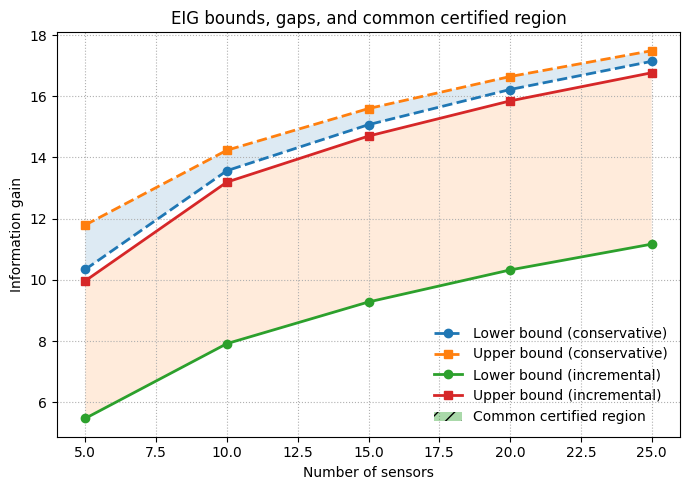

In [94]:
offset = eig_mem # mémoire spectrale
print(f"eig : {offset}")

# Bornes conservatrices
lb_cons_1 = np.array(lb_vals_cons) + offset
ub_cons_1 = np.array(ub_vals_cons) + offset
print(lb_cons_1)

# Bornes incrémentales
lb_inc_1 = np.array(lb_vals_inc)
ub_inc_1 = np.array(ub_vals_inc)

# Intersection des intervalles
lb_common = np.maximum(lb_cons_1, lb_inc_1)
ub_common = np.minimum(ub_cons_1, ub_inc_1)
mask = lb_common <= ub_common


# ===============================
# Figure
# ===============================

fig, ax = plt.subplots(figsize=(7, 5))

# --- Conservatif
ax.plot(sensor_budgets, lb_cons_1,
        '--o', linewidth=2,
        label='Lower bound (conservative)')
ax.plot(sensor_budgets, ub_cons_1,
        '--s', linewidth=2,
        label='Upper bound (conservative)')

ax.fill_between(sensor_budgets,
                lb_cons_1, ub_cons_1,
                alpha=0.15)

# --- Incrémental
ax.plot(sensor_budgets, lb_inc_1,
        '-o', linewidth=2,
        label='Lower bound (incremental)')
ax.plot(sensor_budgets, ub_inc_1,
        '-s', linewidth=2,
        label='Upper bound (incremental)')

ax.fill_between(sensor_budgets,
                lb_inc_1, ub_inc_1,
                alpha=0.15)

# --- Zone commune (mise en valeur)
ax.fill_between(sensor_budgets,
                lb_common, ub_common,
                where=mask,
                interpolate=True,
                alpha=0.4,
                hatch='//',
                label='Common certified region')

# ===============================
# Mise en forme
# ===============================

ax.set_xlabel("Number of sensors")
ax.set_ylabel("Information gain")
ax.set_title("EIG bounds, gaps, and common certified region")

ax.grid(True, which='both', linestyle=':', linewidth=0.8)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

### Sanity check: greedy BI design — global bounds only

In [95]:
sensor_budgets = [5, 10,15,20,25]
lb_vals = []
ub_vals = []

lb_vals_inc = []
ub_vals_inc = []
Sigma_obs = noise.get_covariance(N)

for budget in sensor_budgets:
    indices = greedy_maximize_LB(
        Sigma_Y=Sigma_Y,
        Sigma_noise=Sigma_obs,
        n_sensors=budget
    )
    W_opt_get_conservative, _ = build_selection_matrices(N, indices)

    lb = eig_BI(Sigma_Y, Sigma_obs, W_opt_get_conservative)
    ub = eig_BS(Sigma_signal, Sigma_obs, W_opt_get_conservative)

    lb_inc, ub_inc = incremental_bounds_given_W(
        Sigma_signal  = Sigma_signal,
        Sigma_Y_theta = Sigma_obs,
        Sigma_Y       = Sigma_Y,
        Sigma_noise   = Sigma_obs,
        W = W_opt_get_conservative,       
    )

    lb_vals.append(lb)
    ub_vals.append(ub)

    lb_vals_inc.append(lb_inc)
    ub_vals_inc.append(ub_inc)
    # print(60*"*")
    # print(indices)

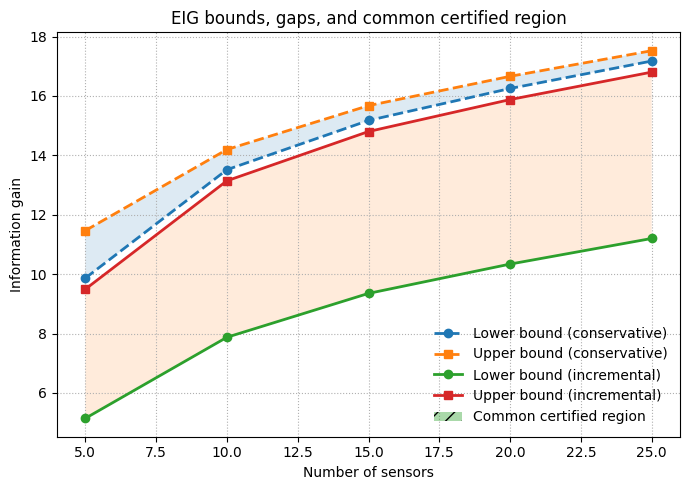

In [96]:
# ===============================
# Préparation des données
# ===============================

offset = eig_mem  # mémoire spectrale

# Bornes conservatrices
lb_cons = np.array(lb_vals) + offset
ub_cons = np.array(ub_vals) + offset

# Bornes incrémentales
lb_inc = np.array(lb_vals_inc)
ub_inc = np.array(ub_vals_inc)

# Intersection des intervalles
lb_common = np.maximum(lb_cons, lb_inc)
ub_common = np.minimum(ub_cons, ub_inc)
mask = lb_common <= ub_common


# ===============================
# Figure
# ===============================

fig, ax = plt.subplots(figsize=(7, 5))

# --- Conservatif
ax.plot(sensor_budgets, lb_cons,
        '--o', linewidth=2,
        label='Lower bound (conservative)')
ax.plot(sensor_budgets, ub_cons,
        '--s', linewidth=2,
        label='Upper bound (conservative)')

ax.fill_between(sensor_budgets,
                lb_cons, ub_cons,
                alpha=0.15)

# --- Incrémental
ax.plot(sensor_budgets, lb_inc,
        '-o', linewidth=2,
        label='Lower bound (incremental)')
ax.plot(sensor_budgets, ub_inc,
        '-s', linewidth=2,
        label='Upper bound (incremental)')

ax.fill_between(sensor_budgets,
                lb_inc, ub_inc,
                alpha=0.15)

# --- Zone commune (mise en valeur)
ax.fill_between(sensor_budgets,
                lb_common, ub_common,
                where=mask,
                interpolate=True,
                alpha=0.4,
                hatch='//',
                label='Common certified region')

# ===============================
# Mise en forme
# ===============================

ax.set_xlabel("Number of sensors")
ax.set_ylabel("Information gain")
ax.set_title("EIG bounds, gaps, and common certified region")

ax.grid(True, which='both', linestyle=':', linewidth=0.8)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

In [45]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import multiprocessing

def generate_chunk(G, n_samples, prior, Sigma_obs, seed):
    torch.manual_seed(seed)
    mu = torch.as_tensor(prior.mu, dtype=torch.float32)
    cov = torch.as_tensor(prior.Sigma, dtype=torch.float32)
    Sigma_obs = torch.as_tensor(Sigma_obs, dtype=torch.float32)
    dim_y = Sigma_obs.shape[0]
    
    y_list = []
    target_list = []
    for _ in range(n_samples):
        theta = torch.distributions.MultivariateNormal(mu, cov).sample()   # shape (dim_theta,)
        # Convertir theta en numpy car G attend un numpy array
        theta_np = theta.numpy()
        G_val = G(theta_np)   # numpy array de shape (dim_y,)
        eps = torch.distributions.MultivariateNormal(torch.zeros(dim_y), Sigma_obs).sample()
        y = torch.tensor(G_val, dtype=torch.float32) + eps
        target = torch.tensor(G_val, dtype=torch.float32)
        y_list.append(y.numpy())
        target_list.append(target.numpy())
    y = np.stack(y_list, axis=0)
    target = np.stack(target_list, axis=0)
    return y, target

def generate_data_parallel(G, n_samples, prior, Sigma_obs, n_jobs=None):
    if n_jobs is None:
        n_jobs = multiprocessing.cpu_count()
    chunk_size = n_samples // n_jobs
    remainder = n_samples % n_jobs
    sizes = [chunk_size] * n_jobs
    for i in range(remainder):
        sizes[i] += 1
    seeds = range(n_jobs)
    results = Parallel(n_jobs=n_jobs, verbose=10)(
        delayed(generate_chunk)(G, sizes[i], prior, Sigma_obs, seeds[i]) for i in range(n_jobs)
    )
    y_list, target_list = zip(*results)
    y = np.concatenate(y_list, axis=0)
    target = np.concatenate(target_list, axis=0)
    return torch.tensor(y, dtype=torch.float32), torch.tensor(target, dtype=torch.float32)


Génération des données d'entraînement...


[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:  2.2min remaining:  6.6min
[Parallel(n_jobs=8)]: Done   3 out of   8 | elapsed:  2.2min remaining:  3.7min
[Parallel(n_jobs=8)]: Done   4 out of   8 | elapsed:  2.2min remaining:  2.2min
[Parallel(n_jobs=8)]: Done   5 out of   8 | elapsed:  2.2min remaining:  1.3min
[Parallel(n_jobs=8)]: Done   6 out of   8 | elapsed:  2.2min remaining:   44.5s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:  2.3min finished
[Parallel(n_jobs=8)]: Using backend LokyBackend with 8 concurrent workers.


Génération des données de test...


[Parallel(n_jobs=8)]: Done   2 out of   8 | elapsed:   13.6s remaining:   40.9s
[Parallel(n_jobs=8)]: Done   3 out of   8 | elapsed:   14.1s remaining:   23.5s
[Parallel(n_jobs=8)]: Done   4 out of   8 | elapsed:   14.5s remaining:   14.5s
[Parallel(n_jobs=8)]: Done   5 out of   8 | elapsed:   14.5s remaining:    8.7s
[Parallel(n_jobs=8)]: Done   6 out of   8 | elapsed:   14.8s remaining:    4.9s
[Parallel(n_jobs=8)]: Done   8 out of   8 | elapsed:   15.0s finished


Epoch   5 | Train MSE: 0.001265 | Test MSE: 0.001255
Epoch  10 | Train MSE: 0.001181 | Test MSE: 0.001103
Epoch  15 | Train MSE: 0.001154 | Test MSE: 0.001152
Epoch  20 | Train MSE: 0.001130 | Test MSE: 0.001156
Epoch  25 | Train MSE: 0.001113 | Test MSE: 0.001121
Epoch  30 | Train MSE: 0.001094 | Test MSE: 0.001063

Estimation de E[tr Cov(G(θ)|y)] = 0.001063

Matrice estimée de E[Cov(G(θ)|y)] :
tensor([[ 8.7690e-05,  1.6365e-04,  2.2665e-04,  ...,  6.7621e-07,
          1.6644e-06, -6.0306e-06],
        [ 1.6365e-04,  3.2183e-04,  4.4911e-04,  ...,  2.4807e-05,
          1.7306e-05, -4.3259e-06],
        [ 2.2665e-04,  4.4911e-04,  6.3682e-04,  ...,  4.2542e-05,
          2.7316e-05,  2.6297e-06],
        ...,
        [ 6.7621e-07,  2.4807e-05,  4.2542e-05,  ...,  6.7205e-04,
          4.7240e-04,  2.3611e-04],
        [ 1.6644e-06,  1.7306e-05,  2.7316e-05,  ...,  4.7240e-04,
          3.3519e-04,  1.6554e-04],
        [-6.0306e-06, -4.3259e-06,  2.6297e-06,  ...,  2.3611e-04,
      

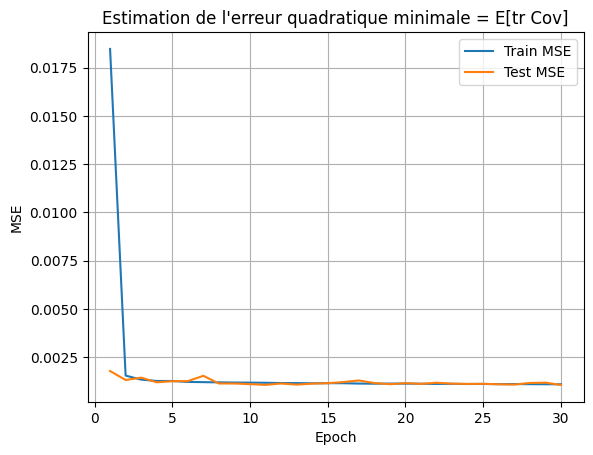

In [55]:
# ---------------------------
# 3. Génération des données (train et test)
# ---------------------------
n_train = 100000
n_test = 10000

Sigma_obs = torch.tensor(noise.get_covariance(N), dtype=torch.float32)

print("Génération des données d'entraînement...")

y_train, target_train = generate_data_parallel(G=G, n_samples = n_train,
                                               prior = prior, Sigma_obs=Sigma_obs)
print("Génération des données de test...")
y_test, target_test = generate_data_parallel(G=G, n_samples = n_test,
                                               prior = prior, Sigma_obs=Sigma_obs)

# DataLoaders avec plusieurs workers pour paralléliser le chargement (CPU)
batch_size = 64
train_dataset = TensorDataset(y_train, target_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=False)
test_dataset = TensorDataset(y_test, target_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, num_workers=2, pin_memory=False)

# ---------------------------
# 4. Définition du réseau (taille modérée pour CPU)
# ---------------------------
class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            prev_dim = h
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

model = SimpleNN(input_dim=N, hidden_dims=[64, 64], output_dim=N)  # plus petit pour CPU

# ---------------------------
# 5. Entraînement sur CPU
# ---------------------------
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 30  # moins d'epochs car CPU plus lent
train_losses = []
test_losses = []

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    for batch_y, batch_target in train_loader:
        optimizer.zero_grad()
        pred = model(batch_y)
        loss = criterion(pred, batch_target)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch_y.size(0)
    train_losses.append(epoch_loss / n_train)
    
    model.eval()
    with torch.no_grad():
        test_loss = 0.0
        for batch_y, batch_target in test_loader:
            pred = model(batch_y)
            loss = criterion(pred, batch_target)
            test_loss += loss.item() * batch_y.size(0)
        test_losses.append(test_loss / n_test)
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:3d} | Train MSE: {train_losses[-1]:.6f} | Test MSE: {test_losses[-1]:.6f}")

# ---------------------------
# 6. Résultat final : estimation de E[tr Cov(G(θ)|y)]
# ---------------------------
final_mse = test_losses[-1]
print(f"\nEstimation de E[tr Cov(G(θ)|y)] = {final_mse:.6f}")

# Matrice de covariance conditionnelle moyenne
model.eval()
residuals = []
with torch.no_grad():
    for batch_y, batch_target in test_loader:
        pred = model(batch_y)
        res = batch_target - pred
        residuals.append(res)
residuals = torch.cat(residuals, dim=0)
mean_res_cov = (residuals.T @ residuals) / len(residuals)
print("\nMatrice estimée de E[Cov(G(θ)|y)] :")
print(mean_res_cov)

# Comparaison avec régression ridge
from sklearn.linear_model import Ridge
y_train_np = y_train.numpy()
target_train_np = target_train.numpy()
y_test_np = y_test.numpy()
target_test_np = target_test.numpy()

ridge = Ridge(alpha=0.1)
ridge.fit(y_train_np, target_train_np)
ridge_pred = ridge.predict(y_test_np)
ridge_mse = np.mean((target_test_np - ridge_pred)**2)
print(f"\nMSE de la régression ridge : {ridge_mse:.6f}")
print(f"Amélioration réseau vs ridge : {ridge_mse - final_mse:.6f}")

# Tracé
plt.figure()
plt.plot(range(1, n_epochs+1), train_losses, label='Train MSE')
plt.plot(range(1, n_epochs+1), test_losses, label='Test MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.title("Estimation de l'erreur quadratique minimale = E[tr Cov]")
plt.grid(True)
plt.show()

In [56]:
Sigma_obs = noise.get_covariance(N)
Sobs_inv = np.linalg.inv(Sigma_obs)
mean_res_cov_np = mean_res_cov.numpy()
Iy = Sobs_inv @ (np.eye(N) - mean_res_cov_np @ Sobs_inv)
Sigma_signal_free_nn = np.linalg.inv(Iy)

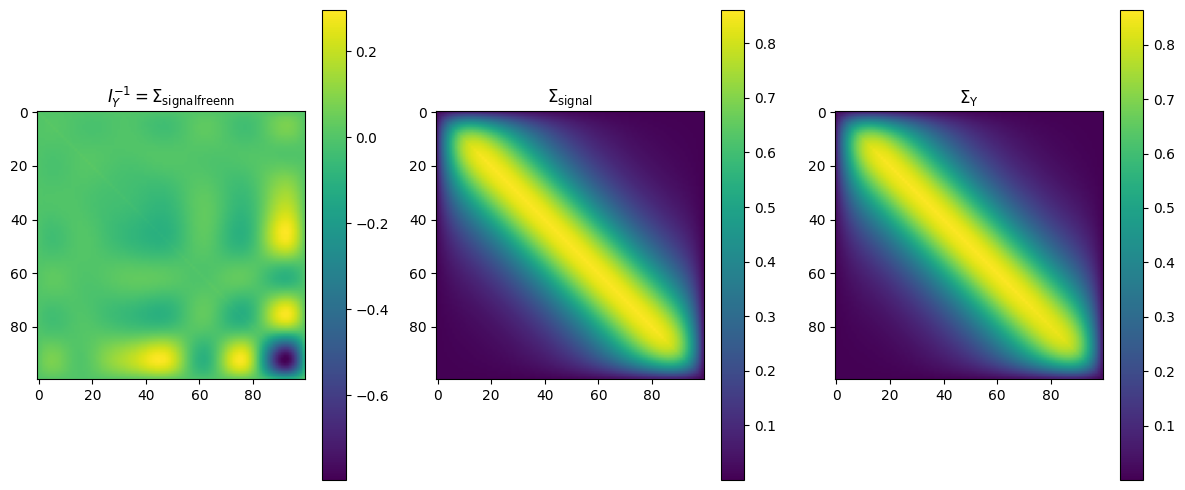

In [57]:
plot_matrices([Sigma_signal_free_nn, Sigma_signal,Sigma_Y], [r"$I_Y^{-1} = \Sigma_{\rm signal free nn}$",r"$\Sigma_{\rm signal}$",r"$\Sigma_{\rm Y}$"], figsize=(12, 5))

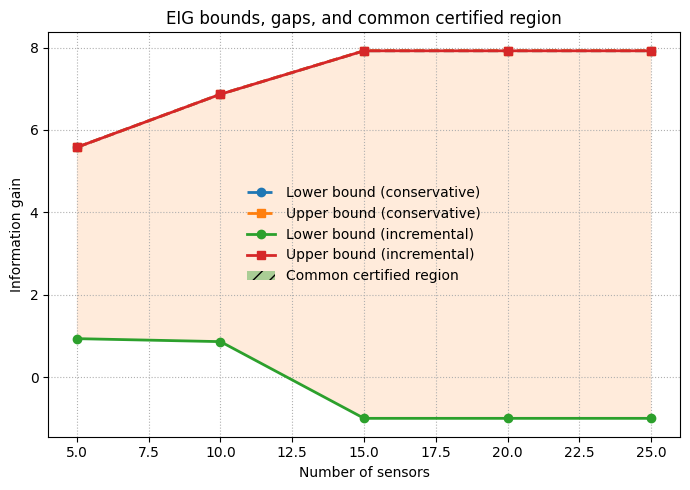

In [58]:
sensor_budgets = [5, 10,15,20,25]
lb_vals = []
ub_vals = []

lb_vals_inc = []
ub_vals_inc = []

Sigma_obs = noise.get_covariance(N)

for budget in sensor_budgets:
    result = incremental_bounds(
        Sigma_signal  = Sigma_signal_free_nn,
        Sigma_Y_theta = Sigma_obs,
        Sigma_Y       = Sigma_Y,
        Sigma_noise   = Sigma_obs,
        n_sensors     = budget,       
    )
    W_opt, _ = build_selection_matrices(N, result['indices'])

    lb = eig_BI(Sigma_Y, Sigma_obs, W_opt)
    ub = eig_BS(Sigma_signal, Sigma_obs, W_opt)

    lb_vals.append(lb)
    ub_vals.append(ub)

    lb_vals_inc.append(result["EIG_lower_bound"])
    ub_vals_inc.append(result["EIG_upper_bound"])


# ===============================
# Préparation des données
# ===============================

offset = eig_mem  # mémoire spectrale

# Bornes conservatrices
lb_cons = lb_vals + offset
ub_cons = ub_vals + offset

# Bornes incrémentales
lb_inc = lb_vals_inc
ub_inc = ub_vals_inc

# Intersection des intervalles
lb_common = np.maximum(lb_cons, lb_inc)
ub_common = np.minimum(ub_cons, ub_inc)
mask = lb_common <= ub_common


# ===============================
# Figure
# ===============================

fig, ax = plt.subplots(figsize=(7, 5))

# --- Conservatif
ax.plot(sensor_budgets, lb_cons,
        '--o', linewidth=2,
        label='Lower bound (conservative)')
ax.plot(sensor_budgets, ub_cons,
        '--s', linewidth=2,
        label='Upper bound (conservative)')

ax.fill_between(sensor_budgets,
                lb_cons, ub_cons,
                alpha=0.15)

# --- Incrémental
ax.plot(sensor_budgets, lb_inc,
        '-o', linewidth=2,
        label='Lower bound (incremental)')
ax.plot(sensor_budgets, ub_inc,
        '-s', linewidth=2,
        label='Upper bound (incremental)')

ax.fill_between(sensor_budgets,
                lb_inc, ub_inc,
                alpha=0.15)

# --- Zone commune (mise en valeur)
ax.fill_between(sensor_budgets,
                lb_common, ub_common,
                where=mask,
                interpolate=True,
                alpha=0.4,
                hatch='//',
                label='Common certified region')

# ===============================
# Mise en forme
# ===============================

ax.set_xlabel("Number of sensors")
ax.set_ylabel("Information gain")
ax.set_title("EIG bounds, gaps, and common certified region")

ax.grid(True, which='both', linestyle=':', linewidth=0.8)
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

In [59]:
print(f"relative error nuc in %: {np.round(np.linalg.norm(Sigma_signal_free_nn-Sigma_signal,ord='nuc')*100/np.linalg.norm(Sigma_signal,ord='nuc'),2)} %")
print(f"relative error fro in %: {np.round(np.linalg.norm(Sigma_signal_free_nn-Sigma_signal,ord='fro')*100/np.linalg.norm(Sigma_signal,ord='fro'),2)} %")
print(f"relative error nuc in %: {np.round(np.linalg.norm(Sigma_signal_free_nn-Sigma_Y,ord='nuc')*100/np.linalg.norm(Sigma_Y,ord='nuc'),2)} %")
print(f"relative error fro in %: {np.round(np.linalg.norm(Sigma_signal_free_nn-Sigma_Y,ord='fro')*100/np.linalg.norm(Sigma_Y,ord='nuc'),2)} %")

relative error nuc in %: 111.74 %
relative error fro in %: 105.61 %
relative error nuc in %: 111.76 %
relative error fro in %: 62.01 %
